# Skeleton

This skeleton should give you a good starting point.
We load the train and test data and write the submission file needed for Kaggle.
So, you can fully concentrate on data analysis and creating models.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


# Prepare data

First, we will load and transform our data. The transformation could be anything from splitting the data, encoding features (OneHotEncoding), adding new features, or basic feature engineering. In this skeleton, we only split the data into the train set (X_train, y_train) and validation set (X_val, y_val).

Note, we don't have to create a test set first here, because the test set was already created by us and is in "houses_test.csv".
We will use that test set at the end of the day on our _final model choice_, as a final estimation on how well our model is on unseen data.

In [60]:
# Load the train data
train_data = pd.read_csv('../data/houses_train.csv', index_col=0)

In [61]:
# Split data into features and labels.
X_data = train_data.drop(columns='price')
y_data = train_data['price']

y_log_data = np.log(y_data)

In [62]:
# Split features and labels into train (X_train, y_train) and validation set (X_val, y_val).
X_train, X_val, y_train, y_val = train_test_split(X_data, y_data, stratify=X_data['object_type_name'], test_size=0.1)
X_train, X_val, y_log_train, y_log_val = train_test_split(X_data, y_log_data, stratify=X_data['object_type_name'], test_size=0.1)

# Data Analysis

We recommend you always start with data analysis, to understand the data better.

In [9]:
train_data.describe()

,lat,long,zipcode,build_year,living_area,num_rooms,water_percentage_1000,travel_time_private_transport,travel_time_public_transport,number_of_buildings_in_hectare,number_of_apartments_in_hectare,number_of_workplaces_in_hectare,number_of_workplaces_sector_1_in_hectare,number_of_workplaces_sector_2_in_hectare,number_of_workplaces_sector_3_in_hectare,population_in_hectare,price
count,20313.000000,20313.000000,20313.000000,20313.000000,20313.000000,20313.000000,2.031300e+04,20313.000000,20313.000000,20313.000000,20313.000000,20313.000000,20313.000000,20313.000000,20313.000000,20313.000000,2.031300e+04
mean,47.115240,8.243116,5844.680352,1979.861222,154.635075,4.970260,3.606663e-02,32.633683,53.984739,8.846207,21.186038,2.994437,0.167282,0.719392,2.604539,42.562251,9.614752e+05
std,0.432648,0.785175,2385.369216,63.116038,100.498345,1.952712,8.195149e-02,22.127187,36.625834,5.736250,17.393235,4.802020,0.691818,1.308216,4.503720,39.227625,5.438531e+05
min,45.879650,5.992815,1000.000000,1.000000,17.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.050000e+05
25%,46.871223,7.620374,4104.000000,1972.000000,108.000000,4.000000,1.683527e-07,18.000000,28.000000,5.000000,9.000000,0.000000,0.000000,0.000000,0.000000,16.000000,6.000000e+05
50%,47.259365,8.274725,5722.000000,1992.000000,138.000000,5.000000,4.769363e-03,28.000000,47.000000,8.000000,17.000000,3.000000,0.000000,0.000000,3.000000,32.000000,8.300000e+05
75%,47.441502,8.790168,8231.000000,2010.000000,175.000000,6.000000,2.595080e-02,40.000000,74.000000,12.000000,29.000000,3.000000,0.000000,0.000000,3.000000,57.000000,1.180000e+06
max,47.793530,10.459287,9658.000000,2108.000000,1999.000000,65.000000,6.312276e-01,161.000000,267.000000,79.000000,211.000000,268.000000,6.000000,18.000000,250.000000,467.000000,3.999000e+06


Shape of dataset (20313, 19)
Missing data percentage: lat                                         0.0
long                                        0.0
zipcode                                     0.0
municipality_name                           0.0
build_year                                  0.0
object_type_name                            0.0
living_area                                 0.0
num_rooms                                   0.0
water_percentage_1000                       0.0
travel_time_private_transport               0.0
travel_time_public_transport                0.0
number_of_buildings_in_hectare              0.0
number_of_apartments_in_hectare             0.0
number_of_workplaces_in_hectare             0.0
number_of_workplaces_sector_1_in_hectare    0.0
number_of_workplaces_sector_2_in_hectare    0.0
number_of_workplaces_sector_3_in_hectare    0.0
population_in_hectare                       0.0
price                                       0.0
dtype: float64


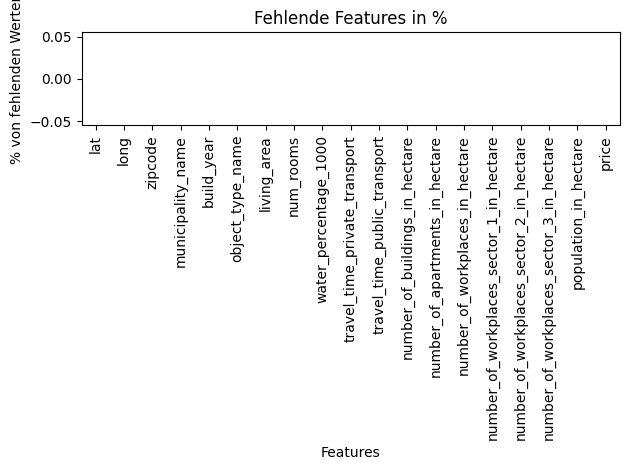

In [5]:
# TODO: Do your data analysis here

print(f"Shape of dataset {train_data.shape}")

missing_data = (train_data.isnull().sum() / len(train_data)) * 100
print(f"Missing data percentage: {missing_data}")

b = sns.barplot(x=missing_data.index, y=missing_data)
plt.xlabel('Features')
plt.ylabel('% von fehlenden Werten')
plt.title('Fehlende Features in %')
plt.xticks(rotation='vertical')
plt.tight_layout()
for text in b.get_xticklabels():
    text.set_text(text.get_text().replace("_", " ").title())
plt.show()


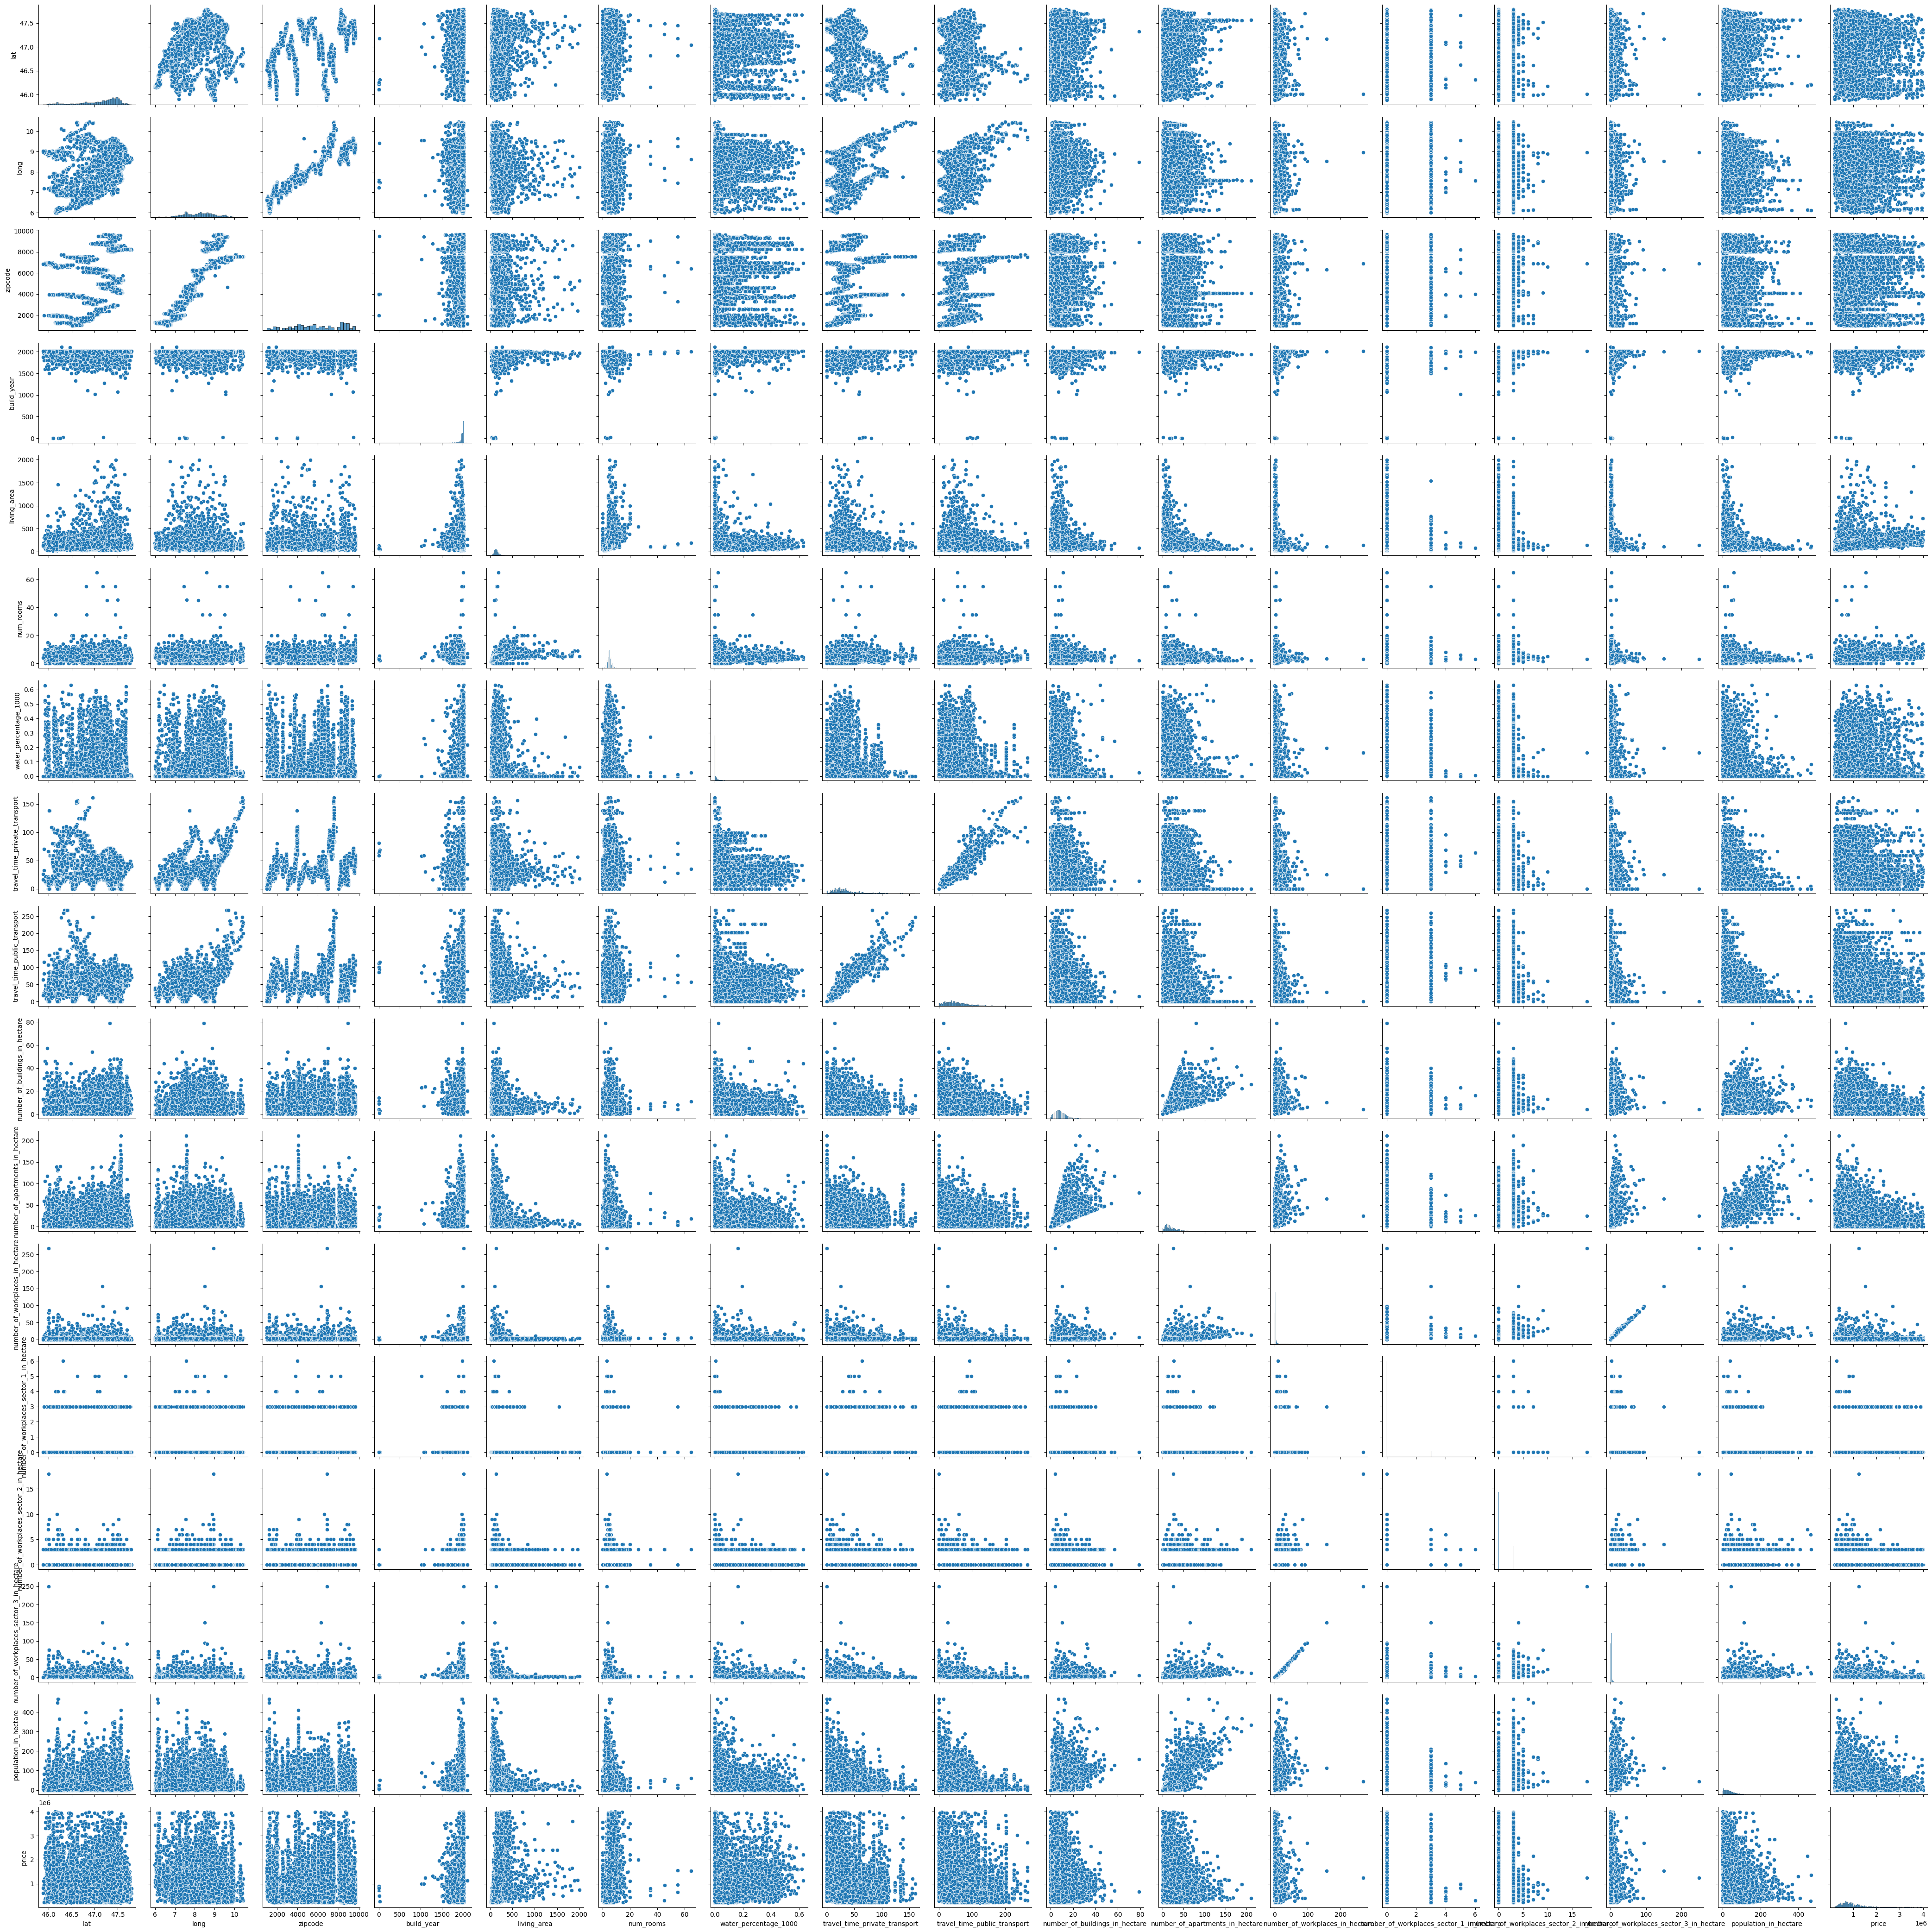

In [7]:
# Create sns pair plot
sns.pairplot(train_data)
plt.xticks(rotation='vertical')

plt.show()

/tmp/ipykernel_14635/2002701653.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(train_data['object_type_name'].unique(), rotation=90)


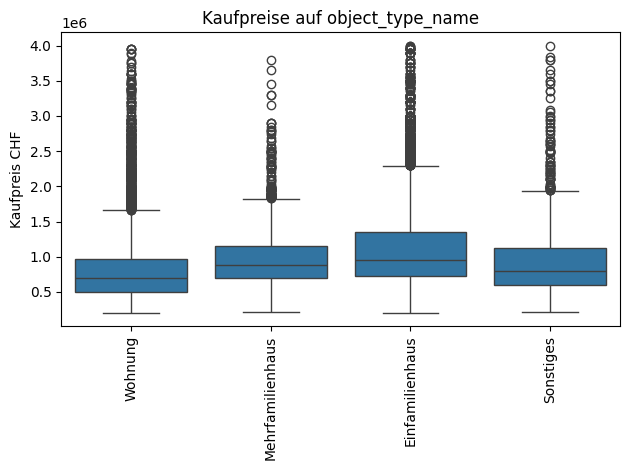

In [15]:
ax = plt.axes()
b = sns.boxplot(x='object_type_name', y='price', data=train_data, ax=ax)
b.set_xticklabels(train_data['object_type_name'].unique(), rotation=90)
ax.set_xlabel("")
ax.set_ylabel("Kaufpreis CHF")
ax.set_title("Kaufpreise auf object_type_name")
plt.tight_layout()
plt.show()


/tmp/ipykernel_14635/2554597184.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_data['price'], kde=True, bins=50, ax=ax)


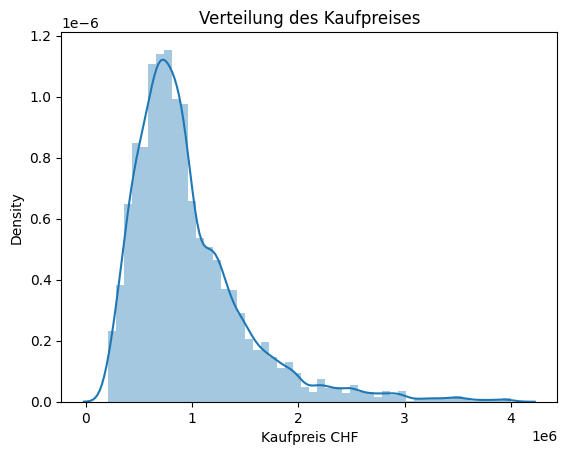

/tmp/ipykernel_14635/2554597184.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_data['log_price'], kde=True, bins=50, ax=ax)


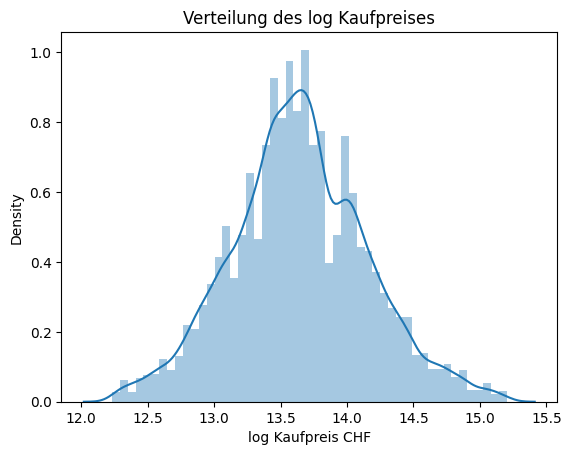

In [17]:
ax = plt.axes()
ax.set_title("Verteilung des Kaufpreises")
sns.distplot(train_data['price'], kde=True, bins=50, ax=ax)
ax.set_xlabel("Kaufpreis CHF")
plt.show()


# log price to reduce skewness
train_data['log_price'] = np.log(train_data['price'])
ax = plt.axes()
ax.set_title("Verteilung des log Kaufpreises")
sns.distplot(train_data['log_price'], kde=True, bins=50, ax=ax)
ax.set_xlabel("log Kaufpreis CHF")
plt.show()


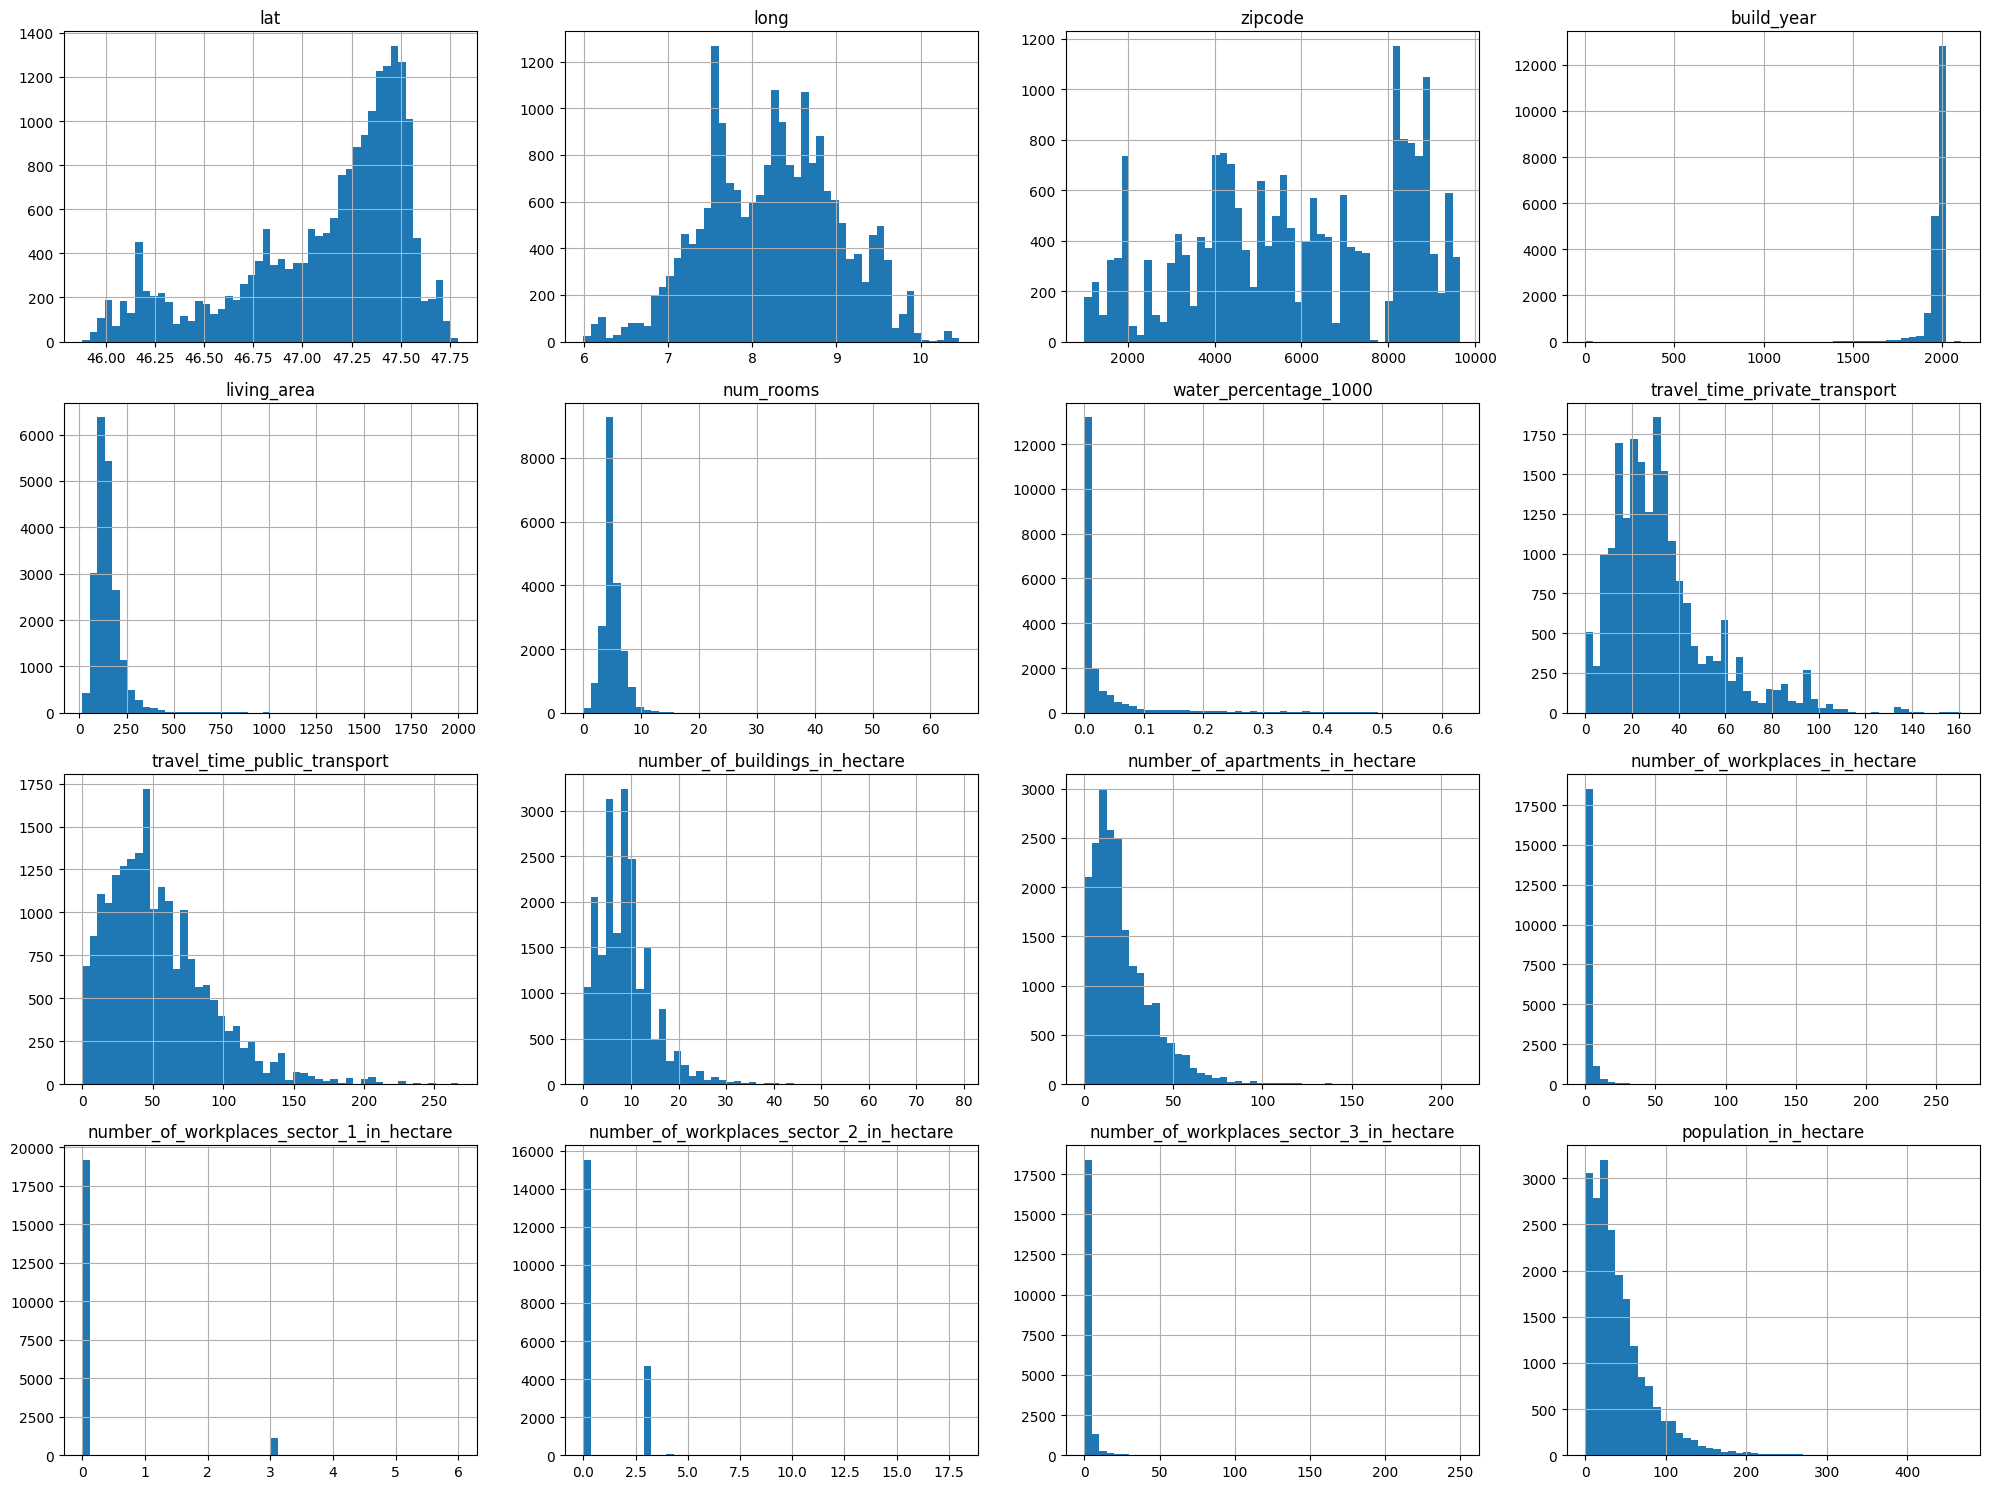

In [68]:
# Create a histogram over all numeric features
numeric_cols = train_data.select_dtypes(include=['float64', 'int64']).columns.drop(['price'])
train_data[numeric_cols].hist(bins=50, figsize=(20, 15))
plt.tight_layout()
plt.show()

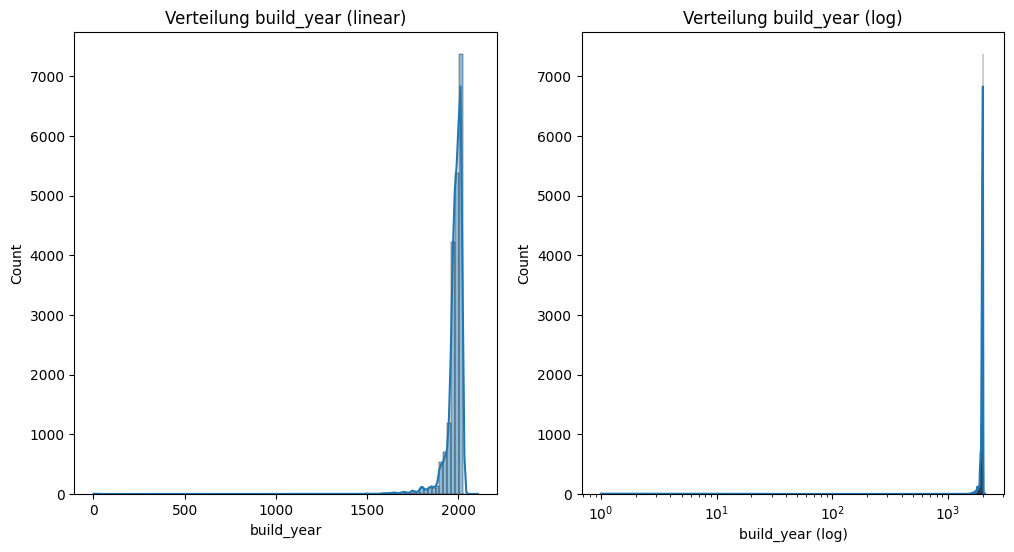

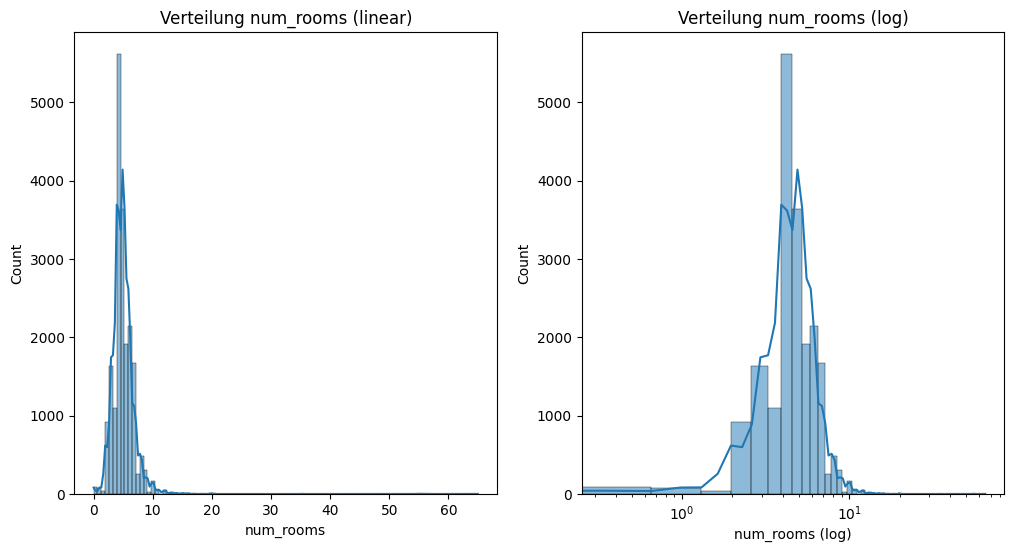

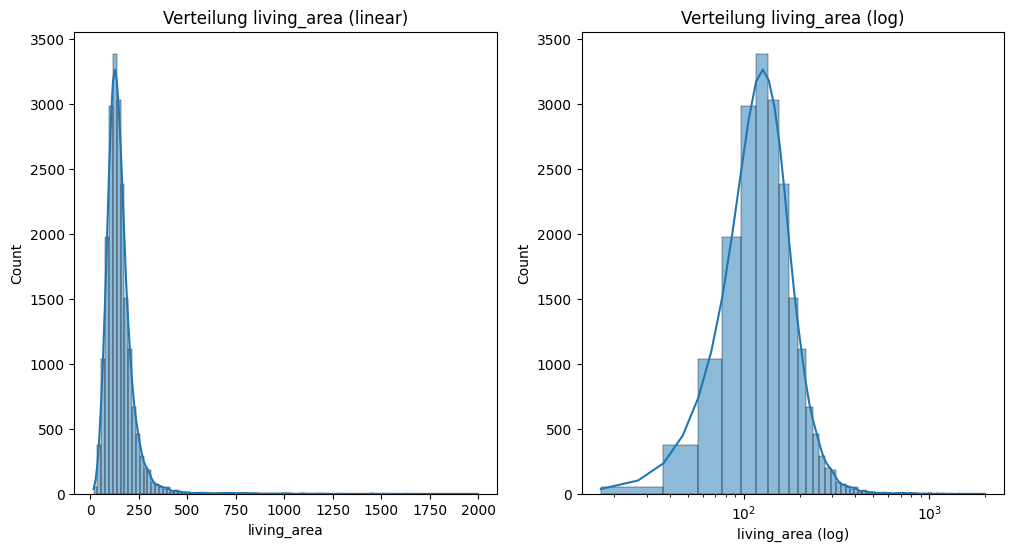

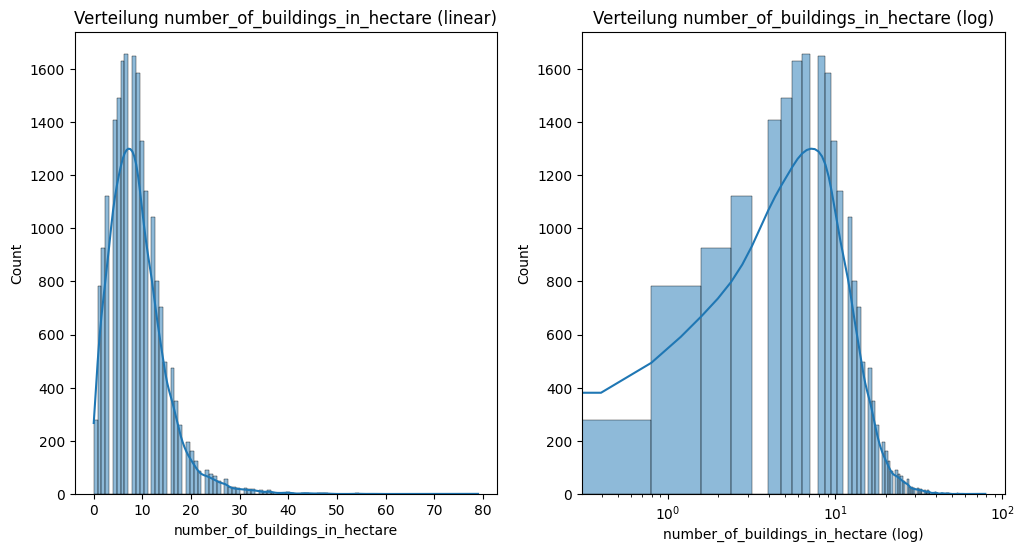

In [36]:
# Create two histogram plots for one feature. The right should have a log scale on the x axsis.


for feature in ['build_year', 'num_rooms', 'living_area', 'number_of_buildings_in_hectare']:

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    # Linear scale
    axes[0].set_title(f"Verteilung {feature} (linear)")
    sns.histplot(train_data[feature], kde=True, bins=100, ax=axes[0])
    axes[0].set_xlabel(f"{feature}")

    # Log scale
    axes[1].set_title(f"Verteilung {feature} (log)")
    sns.histplot(train_data[feature], kde=True, bins=100, ax=axes[1])
    axes[1].set_xscale('log')
    axes[1].set_xlabel(f"{feature} (log)")

    plt.show()

In [19]:
train_data.dtypes

lat                                         float64
long                                        float64
zipcode                                       int64
municipality_name                               str
build_year                                    int64
object_type_name                                str
living_area                                 float64
num_rooms                                   float64
water_percentage_1000                       float64
travel_time_private_transport               float64
travel_time_public_transport                float64
number_of_buildings_in_hectare                int64
number_of_apartments_in_hectare             float64
number_of_workplaces_in_hectare               int64
number_of_workplaces_sector_1_in_hectare      int64
number_of_workplaces_sector_2_in_hectare      int64
number_of_workplaces_sector_3_in_hectare      int64
population_in_hectare                         int64
price                                       float64
log_price   

/tmp/ipykernel_14635/2966239804.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_data[f].dropna(), kde=False, bins=100, hist_kws={'alpha': 0.6}, ax=ax)


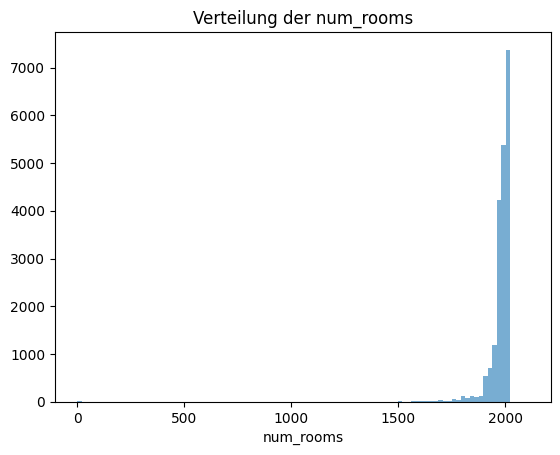

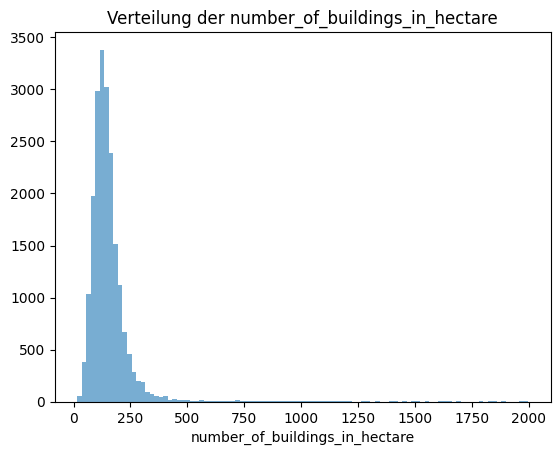

In [22]:
for f, name in [('build_year', 'num_rooms'), ('living_area', 'number_of_buildings_in_hectare')]:
    ax = plt.axes()
    ax.set_title("Verteilung der {}".format(name))
    sns.distplot(train_data[f].dropna(), kde=False, bins=100, hist_kws={'alpha': 0.6}, ax=ax)
    ax.set_xlabel("{}".format(name))
    plt.show()


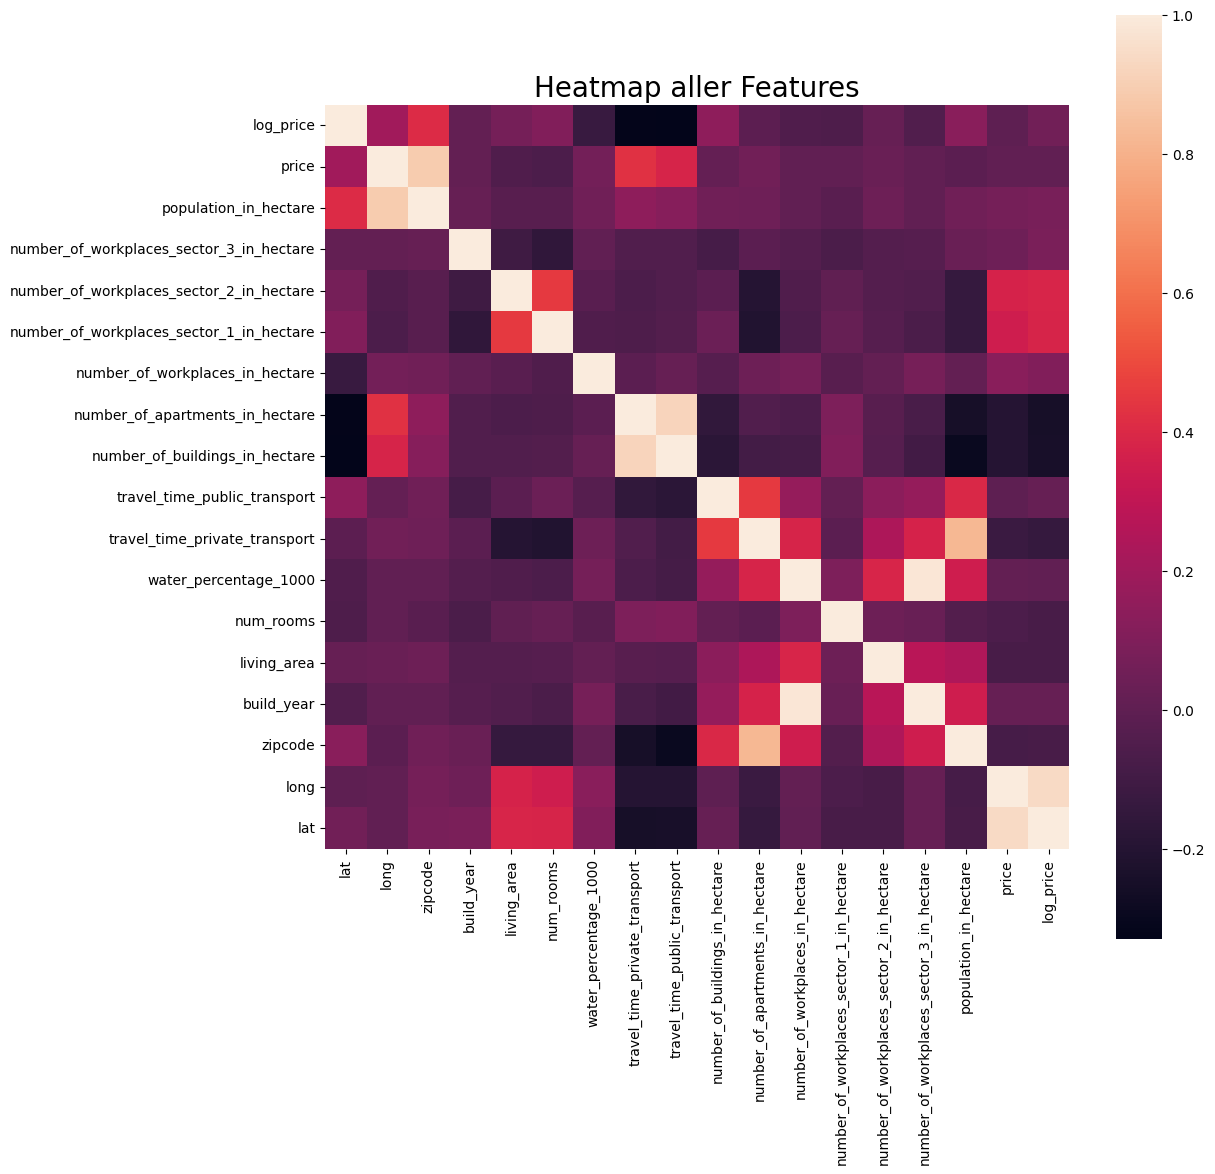

In [52]:
corr = train_data.select_dtypes(include = ['float64', 'int64']).corr()
plt.figure(figsize=(12, 12))
hm = sns.heatmap(corr, square=True)
for text in hm.get_xticklabels():
    text.set_text(text.get_text().replace("_", " ").replace("id", "").title())
hm.set_xticklabels(hm.get_xticklabels(), rotation=90)
hm.set_yticklabels(reversed(hm.get_xticklabels()), rotation=0)
hm.set_title("Heatmap aller Features", fontsize=20)
plt.show()

In [25]:
cor_dict = corr['price'].to_dict()
del cor_dict['price']
del cor_dict['log_price']
print("List the numerical features decendingly by their correlation with Sale Price:\n")
for ele in sorted(cor_dict.items(), key = lambda x: -abs(x[1])):
    print("{0}: \t{1}".format(*ele))

List the numerical features decendingly by their correlation with Sale Price:

living_area: 	0.37515282983166115
num_rooms: 	0.3496741952126167
travel_time_private_transport: 	-0.19679813654867823
travel_time_public_transport: 	-0.19584812601736207
water_percentage_1000: 	0.12947901447636276
number_of_apartments_in_hectare: 	-0.1252188102681688
population_in_hectare: 	-0.08433374772256057
number_of_workplaces_sector_2_in_hectare: 	-0.07462986188594042
zipcode: 	0.0683469025132807
number_of_workplaces_sector_1_in_hectare: 	-0.06243867173125117
build_year: 	0.04906915086115629
number_of_workplaces_sector_3_in_hectare: 	0.023876777549088797
number_of_workplaces_in_hectare: 	0.010384462571315126
long: 	0.006895368518541259
lat: 	-0.005942993110736797
number_of_buildings_in_hectare: 	-0.003260602086043523


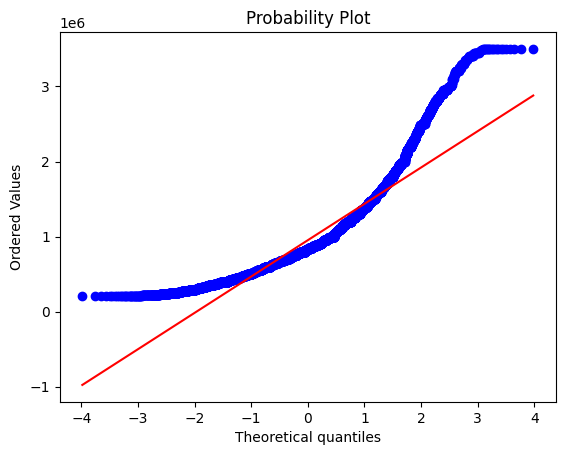

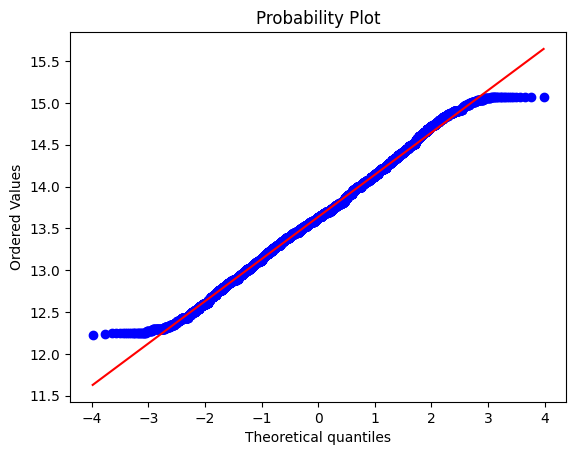

In [27]:
fig = plt.figure()
from scipy import stats
res = stats.probplot(train_data['price'], plot=plt)
plt.show()
fig = plt.figure()
res = stats.probplot(train_data['log_price'], plot=plt)
plt.show()


MAPE for feature living_area: 0.45


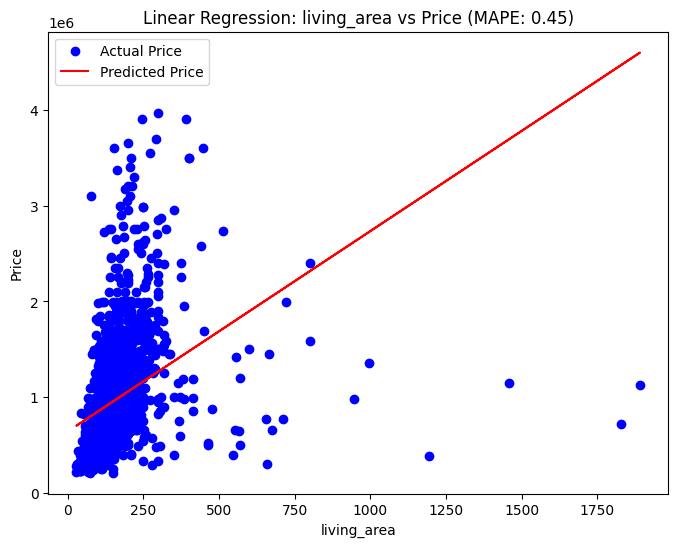

MAPE for feature num_rooms: 0.45


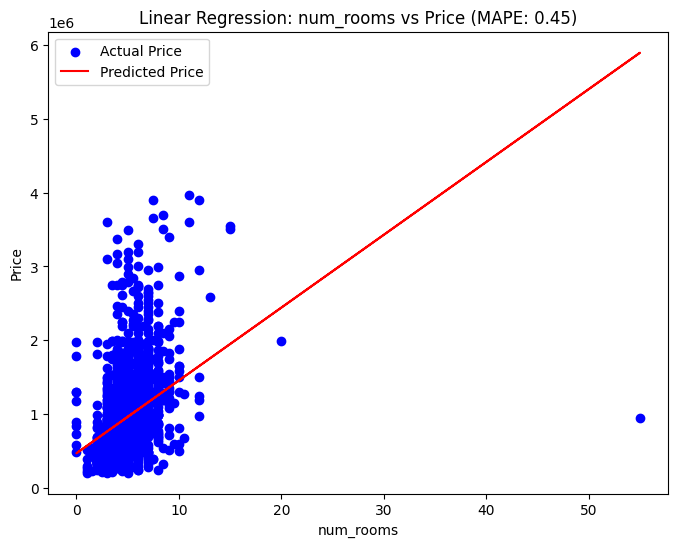

MAPE for feature travel_time_private_transport: 0.50


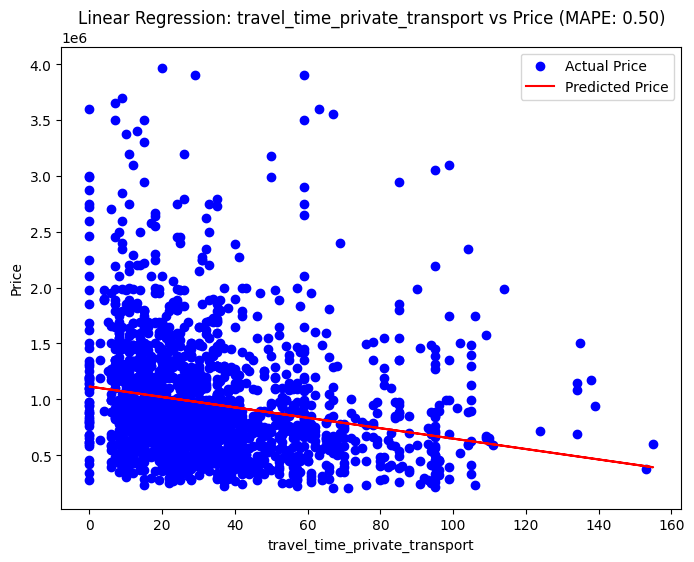

In [32]:
# Lineare regression with living area with mape mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error


for f in ['living_area', 'num_rooms', 'travel_time_private_transport']:

    X_train_feature = X_train[[f]].fillna(0)
    X_val_feature = X_val[[f]].fillna(0)

    model = LinearRegression()
    model.fit(X_train_feature, y_train)
    y_pred = model.predict(X_val_feature)
    mape = mean_absolute_percentage_error(y_val, y_pred)
    print(f"MAPE for feature {f}: {mape:.2f}")


    # Plot the linear regression results
    plt.figure(figsize=(8, 6))
    plt.scatter(X_val_feature, y_val, color='blue', label='Actual Price')
    plt.plot(X_val_feature, y_pred, color='red', label='Predicted Price')
    plt.xlabel(f)
    plt.ylabel('Price')
    plt.title(f'Linear Regression: {f} vs Price (MAPE: {mape:.2f})')
    plt.legend()
    plt.show()


MAPE for feature living_area: 0.33


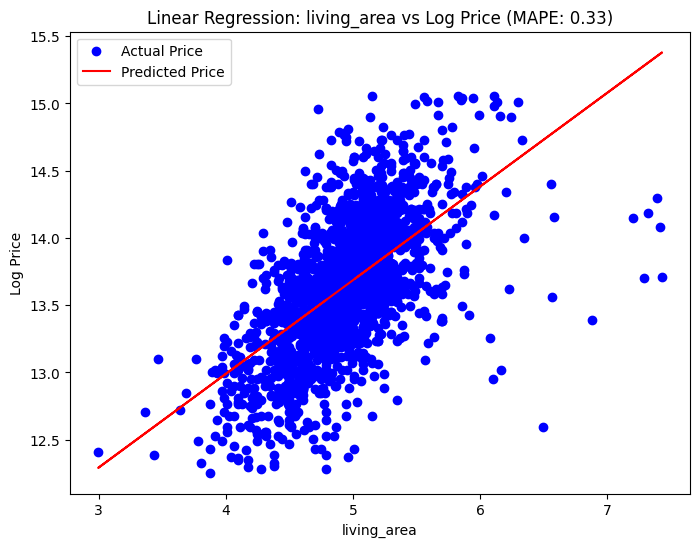

In [45]:

for f in ['living_area']:

    X_train_feature = np.log(X_train[[f]])
    X_val_feature = np.log(X_val[[f]])

    model = LinearRegression()
    model.fit(X_train_feature, y_log_train)
    y_pred = model.predict(X_val_feature)
    # Calculate MAPE for price not log price
    mape = mean_absolute_percentage_error(np.exp(y_log_val), np.exp(y_pred))
    print(f"MAPE for feature {f}: {mape:.2f}")


    # Plot the linear regression results
    plt.figure(figsize=(8, 6))
    plt.scatter(X_val_feature, y_log_val, color='blue', label='Actual Price')
    plt.plot(X_val_feature, y_pred, color='red', label='Predicted Price')
    plt.xlabel(f)
    plt.ylabel('Log Price')
    plt.title(f'Linear Regression: {f} vs Log Price (MAPE: {mape:.2f})')
    plt.legend()
    plt.show()


MAPE for LinearRegression: 0.3714
MAPE for Ridge: 0.3714
MAPE for RidgeCV: 0.3714
MAPE for Lasso: 0.3845
MAPE for LassoCV: 0.3677
MAPE for LassoLarsCV: 0.3714
MAPE for ElasticNet: 0.3833
MAPE for ElasticNetCV: 0.3676


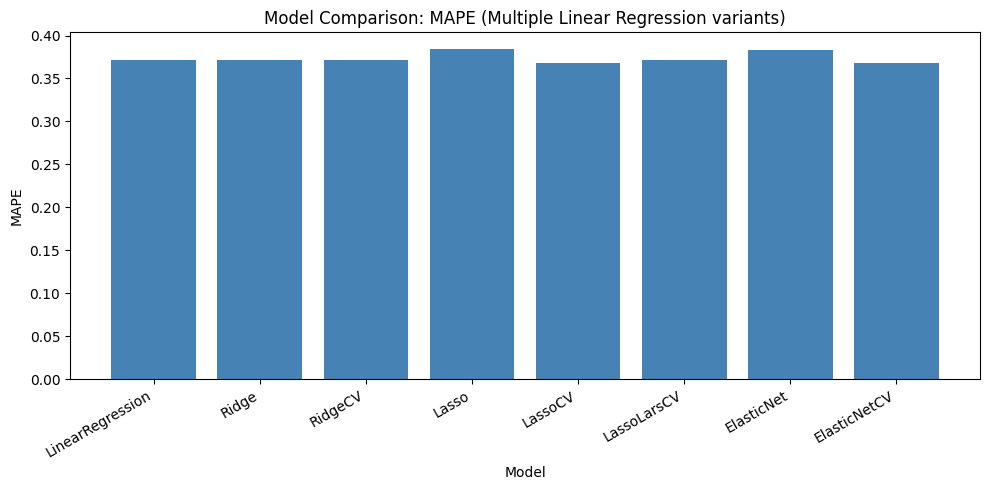

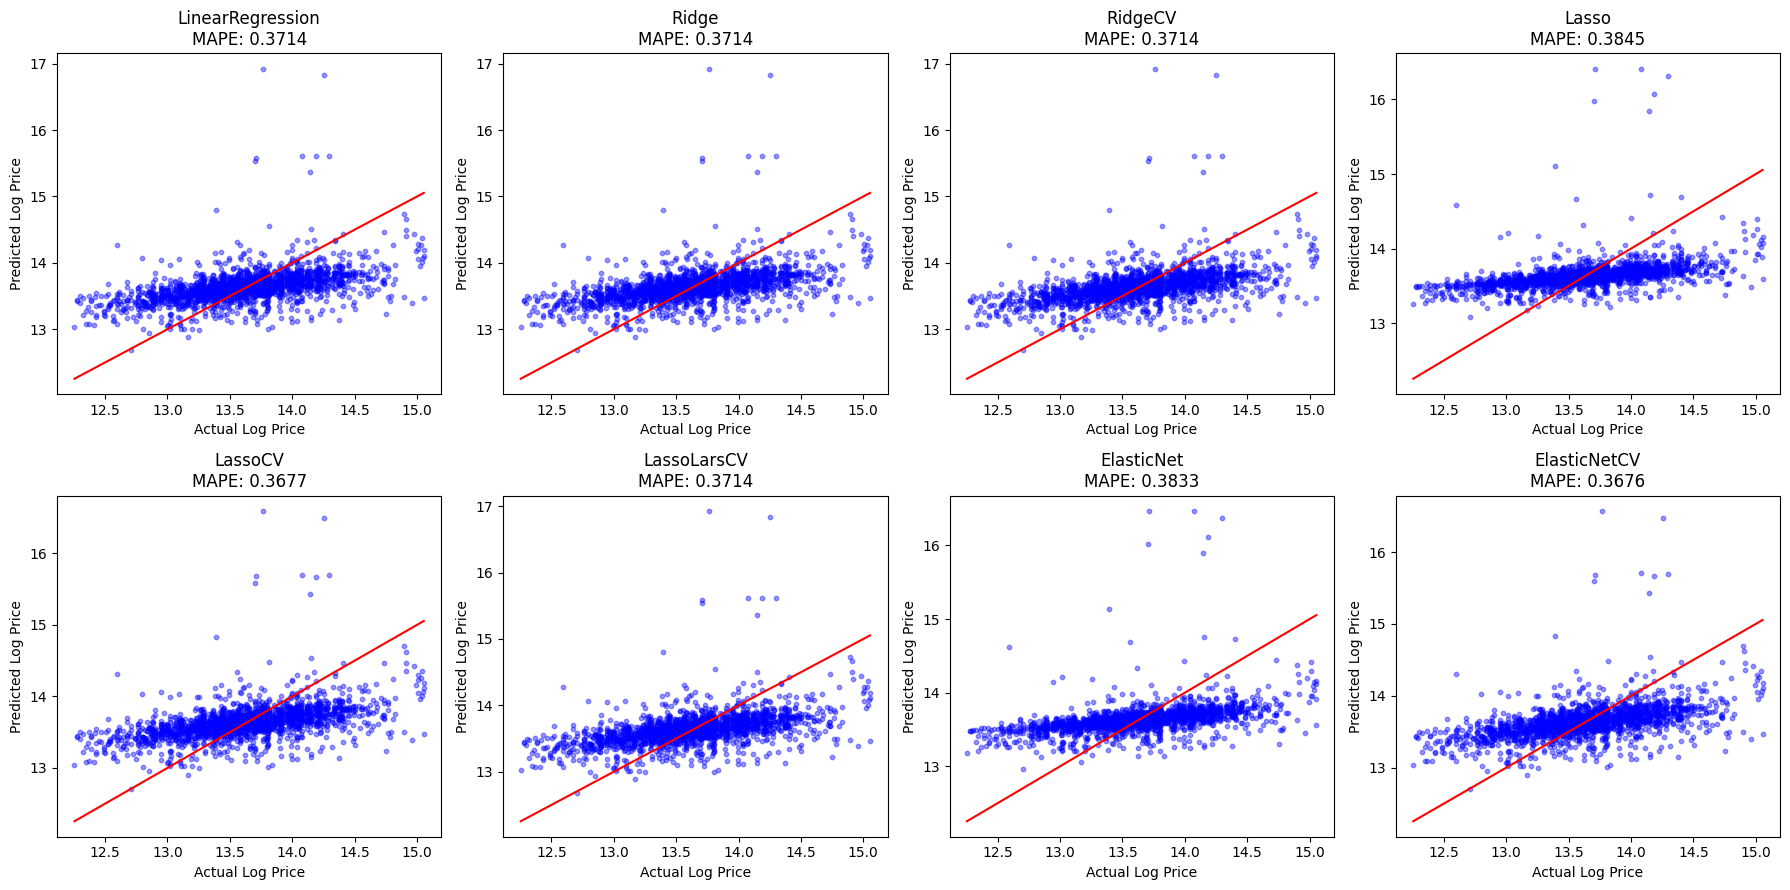

In [49]:

# Create a multiple linear regression model with the three features and log price as target. Calculate the MAPE and plot the results.
# Use different models: LassoLarsCV, Ridge, RidgeCV, LassoCV, Lasso, ElasticNetCV, ElasticNet, LinearRegression and compare the results.

from sklearn.linear_model import (
    LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV, LassoLarsCV
)
from sklearn.metrics import mean_absolute_percentage_error

features = ['living_area', 'num_rooms', 'travel_time_private_transport']
X_train_feat = X_train[features].fillna(0)
X_val_feat = X_val[features].fillna(0)

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'RidgeCV': RidgeCV(),
    'Lasso': Lasso(),
    'LassoCV': LassoCV(cv=5, max_iter=10000),
    'LassoLarsCV': LassoLarsCV(cv=5),
    'ElasticNet': ElasticNet(),
    'ElasticNetCV': ElasticNetCV(cv=5, max_iter=10000),
}

results = {}
for name, model in models.items():
    model.fit(X_train_feat, y_log_train)
    y_pred = model.predict(X_val_feat)
    mape = mean_absolute_percentage_error(np.exp(y_log_val), np.exp(y_pred))
    results[name] = {'mape': mape, 'y_pred': y_pred}
    print(f"MAPE for {name}: {mape:.4f}")

# Bar chart comparing MAPE across models
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), [v['mape'] for v in results.values()], color='steelblue')
plt.xlabel('Model')
plt.ylabel('MAPE')
plt.title('Model Comparison: MAPE (Multiple Linear Regression variants)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Scatter plots: predicted vs actual log price for each model
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for ax, (name, res) in zip(axes, results.items()):
    ax.scatter(y_log_val, res['y_pred'], alpha=0.4, s=10, color='blue')
    ax.plot([y_log_val.min(), y_log_val.max()], [y_log_val.min(), y_log_val.max()], color='red')
    ax.set_title(f"{name}\nMAPE: {res['mape']:.4f}")
    ax.set_xlabel('Actual Log Price')
    ax.set_ylabel('Predicted Log Price')
plt.tight_layout()
plt.show()


Using features: ['lat', 'long', 'zipcode', 'build_year', 'living_area', 'num_rooms', 'water_percentage_1000', 'travel_time_private_transport', 'travel_time_public_transport', 'number_of_buildings_in_hectare', 'number_of_apartments_in_hectare', 'number_of_workplaces_in_hectare', 'number_of_workplaces_sector_1_in_hectare', 'number_of_workplaces_sector_2_in_hectare', 'number_of_workplaces_sector_3_in_hectare', 'population_in_hectare']
MAPE for LinearRegression (log features): 0.2884
MAPE for Ridge (log features): 0.2887
MAPE for RidgeCV (log features): 0.2884
MAPE for Lasso (log features): 0.4217
MAPE for LassoCV (log features): 0.2886
MAPE for LassoLarsCV (log features): 0.2884
MAPE for ElasticNet (log features): 0.4217
MAPE for ElasticNetCV (log features): 0.2895


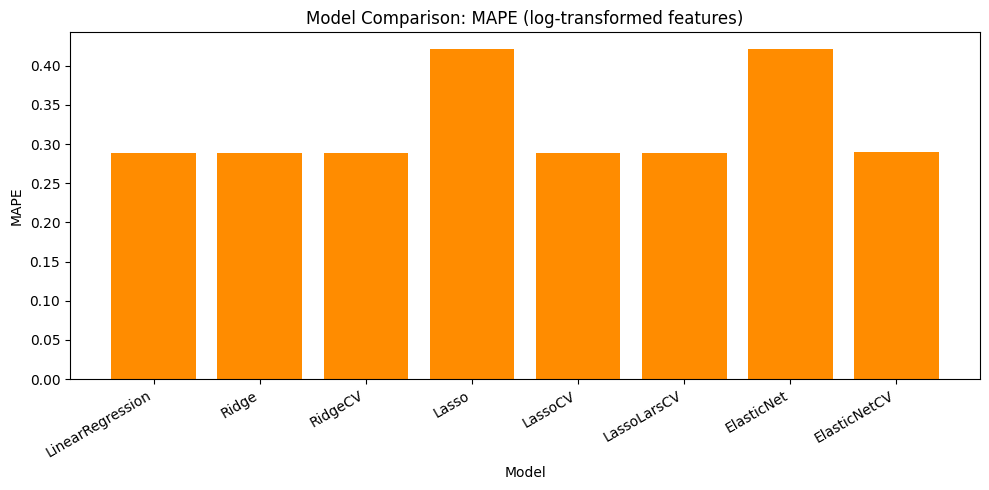

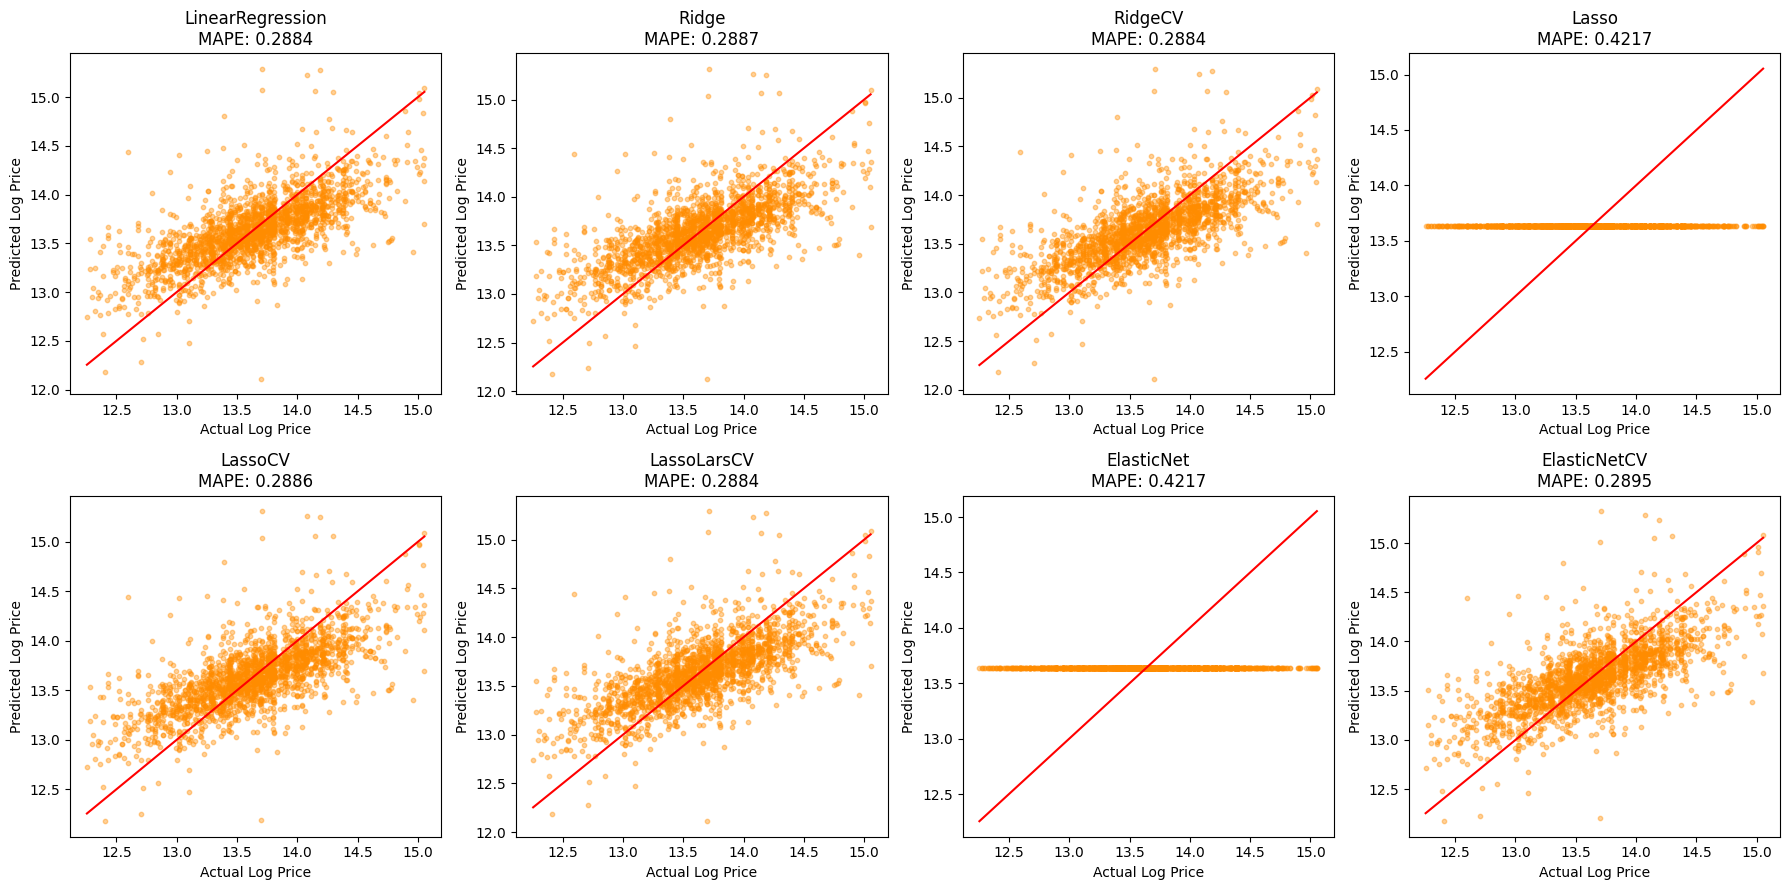

In [51]:

# Same model comparison but with log-transformed features (log1p to handle zeros)

from sklearn.linear_model import (
    LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV, LassoLarsCV
)
from sklearn.metrics import mean_absolute_percentage_error

features = ['living_area', 'num_rooms', 'travel_time_private_transport']
features = train_data.select_dtypes(include = ['float64', 'int64']).columns.drop(['price', 'log_price'])
print(f"Using features: {features.tolist()}")
X_train_log = np.log1p(X_train[features].fillna(0))
X_val_log = np.log1p(X_val[features].fillna(0))

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'RidgeCV': RidgeCV(),
    'Lasso': Lasso(),
    'LassoCV': LassoCV(cv=5, max_iter=10000),
    'LassoLarsCV': LassoLarsCV(cv=5),
    'ElasticNet': ElasticNet(),
    'ElasticNetCV': ElasticNetCV(cv=5, max_iter=10000),
}

results_log = {}
for name, model in models.items():
    model.fit(X_train_log, y_log_train)
    y_pred = model.predict(X_val_log)
    mape = mean_absolute_percentage_error(np.exp(y_log_val), np.exp(y_pred))
    results_log[name] = {'mape': mape, 'y_pred': y_pred}
    print(f"MAPE for {name} (log features): {mape:.4f}")

# Bar chart comparing MAPE across models
plt.figure(figsize=(10, 5))
plt.bar(results_log.keys(), [v['mape'] for v in results_log.values()], color='darkorange')
plt.xlabel('Model')
plt.ylabel('MAPE')
plt.title('Model Comparison: MAPE (log-transformed features)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Scatter plots: predicted vs actual log price for each model
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for ax, (name, res) in zip(axes, results_log.items()):
    ax.scatter(y_log_val, res['y_pred'], alpha=0.4, s=10, color='darkorange')
    ax.plot([y_log_val.min(), y_log_val.max()], [y_log_val.min(), y_log_val.max()], color='red')
    ax.set_title(f"{name}\nMAPE: {res['mape']:.4f}")
    ax.set_xlabel('Actual Log Price')
    ax.set_ylabel('Predicted Log Price')
plt.tight_layout()
plt.show()


/tmp/ipykernel_14635/833641341.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns.tolist()


Kategorische Spalten: ['municipality_name', 'object_type_name']
Shape vor Encoding:  (18281, 18)
Shape nach Encoding: (18281, 1912)
MAPE for LinearRegression (log features): 0.2264
MAPE for Ridge (log features): 0.2224
MAPE for RidgeCV (log features): 0.2224
MAPE for Lasso (log features): 0.4377
MAPE for LassoCV (log features): 0.2462
MAPE for LassoLarsCV (log features): 0.2370
MAPE for ElasticNet (log features): 0.4377
MAPE for ElasticNetCV (log features): 0.2501


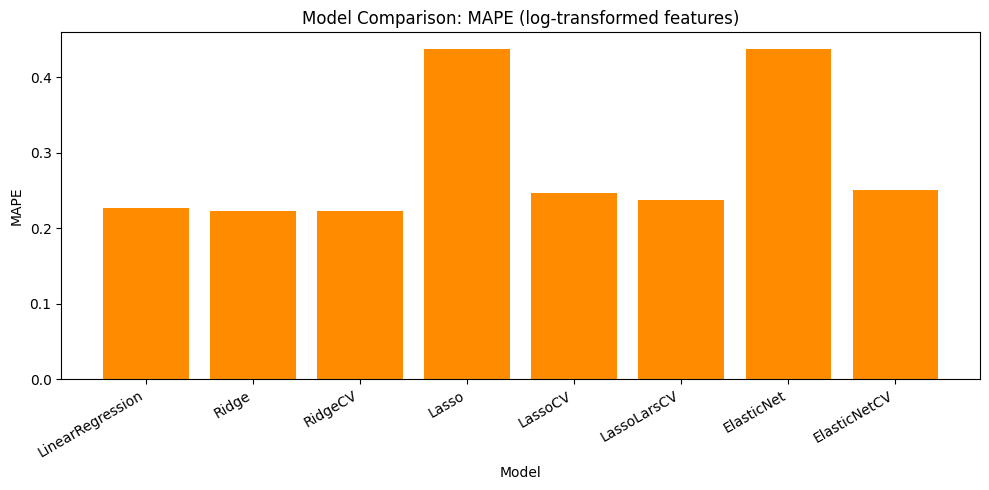

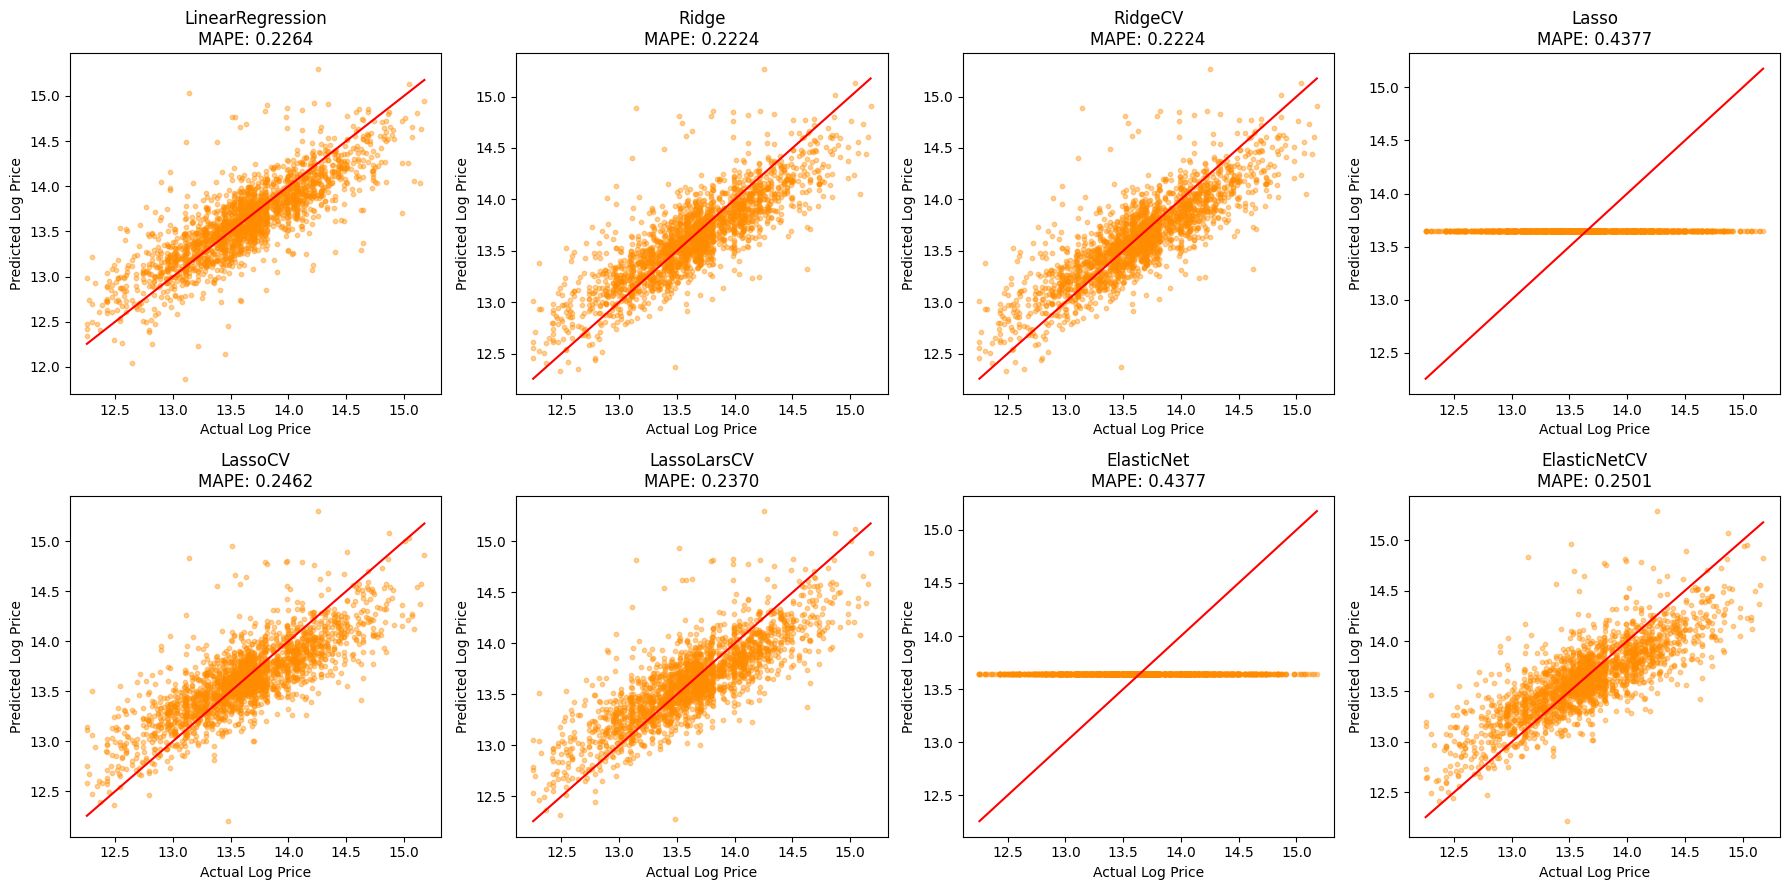

In [63]:

# OneHot Encoding for all string (object) columns
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
print(f"Kategorische Spalten: {cat_cols}")

# Fit encoder on train set only
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[cat_cols])

# Transform both sets
ohe_train = pd.DataFrame(
    ohe.transform(X_train[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train.index
)
ohe_val = pd.DataFrame(
    ohe.transform(X_val[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_val.index
)

# Drop original categorical columns and append encoded ones
X_train_enc = X_train.drop(columns=cat_cols).join(ohe_train)
X_val_enc   = X_val.drop(columns=cat_cols).join(ohe_val)

print(f"Shape vor Encoding:  {X_train.shape}")
print(f"Shape nach Encoding: {X_train_enc.shape}")



X_train_log = np.log1p(X_train_enc)
X_val_log = np.log1p(X_val_enc)

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'RidgeCV': RidgeCV(),
    'Lasso': Lasso(),
    'LassoCV': LassoCV(cv=5, max_iter=10000),
    'LassoLarsCV': LassoLarsCV(cv=5),
    'ElasticNet': ElasticNet(),
    'ElasticNetCV': ElasticNetCV(cv=5, max_iter=10000),
}

results_log = {}
for name, model in models.items():
    model.fit(X_train_log, y_log_train)
    y_pred = model.predict(X_val_log)
    mape = mean_absolute_percentage_error(np.exp(y_log_val), np.exp(y_pred))
    results_log[name] = {'mape': mape, 'y_pred': y_pred}
    print(f"MAPE for {name} (log features): {mape:.4f}")

# Bar chart comparing MAPE across models
plt.figure(figsize=(10, 5))
plt.bar(results_log.keys(), [v['mape'] for v in results_log.values()], color='darkorange')
plt.xlabel('Model')
plt.ylabel('MAPE')
plt.title('Model Comparison: MAPE (log-transformed features)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Scatter plots: predicted vs actual log price for each model
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for ax, (name, res) in zip(axes, results_log.items()):
    ax.scatter(y_log_val, res['y_pred'], alpha=0.4, s=10, color='darkorange')
    ax.plot([y_log_val.min(), y_log_val.max()], [y_log_val.min(), y_log_val.max()], color='red')
    ax.set_title(f"{name}\nMAPE: {res['mape']:.4f}")
    ax.set_xlabel('Actual Log Price')
    ax.set_ylabel('Predicted Log Price')
plt.tight_layout()
plt.show()






In [65]:
X_train.dtypes

lat                                         float64
long                                        float64
zipcode                                       int64
municipality_name                               str
build_year                                    int64
object_type_name                                str
living_area                                 float64
num_rooms                                   float64
water_percentage_1000                       float64
travel_time_private_transport               float64
travel_time_public_transport                float64
number_of_buildings_in_hectare                int64
number_of_apartments_in_hectare             float64
number_of_workplaces_in_hectare               int64
number_of_workplaces_sector_1_in_hectare      int64
number_of_workplaces_sector_2_in_hectare      int64
number_of_workplaces_sector_3_in_hectare      int64
population_in_hectare                         int64
dtype: object

Kategorisch  (3): ['municipality_name', 'object_type_name', 'zipcode']
Log-transform(7): ['living_area', 'num_rooms', 'water_percentage_1000', 'travel_time_private_transport', 'travel_time_public_transport', 'number_of_buildings_in_hectare', 'number_of_apartments_in_hectare']
Numerisch    (9): ['lat', 'long', 'zipcode', 'build_year', 'number_of_workplaces_in_hectare', 'number_of_workplaces_sector_1_in_hectare', 'number_of_workplaces_sector_2_in_hectare', 'number_of_workplaces_sector_3_in_hectare', 'population_in_hectare']
MAPE LinearRegression    : 0.2192
MAPE Ridge               : 0.2188
MAPE RidgeCV             : 0.2179
MAPE Lasso               : 0.4377
MAPE LassoCV             : 0.2121


/home/nima/Documents/FHNW/10_Machine Learning Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 23 iterations, i.e. alpha=2.229e-02, with an active set of 21 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/nima/Documents/FHNW/10_Machine Learning Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 39 iterations, i.e. alpha=1.887e-02, with an active set of 37 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/home/nima/Documents/FHNW/10_Machine Learning Lab/.venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping

MAPE LassoLarsCV         : 0.2664
MAPE ElasticNet          : 0.4377
MAPE ElasticNetCV        : 0.2122


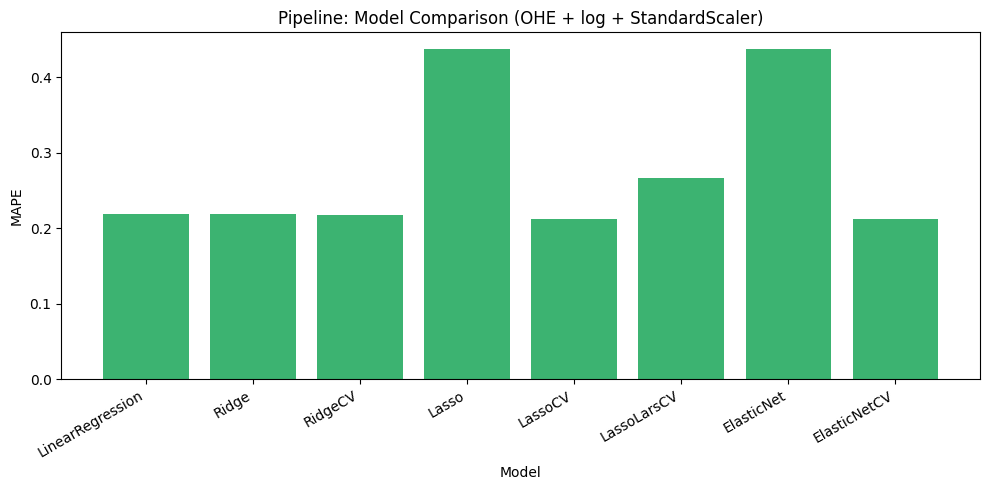


Bestes Modell: LassoCV  (MAPE: 0.2121)


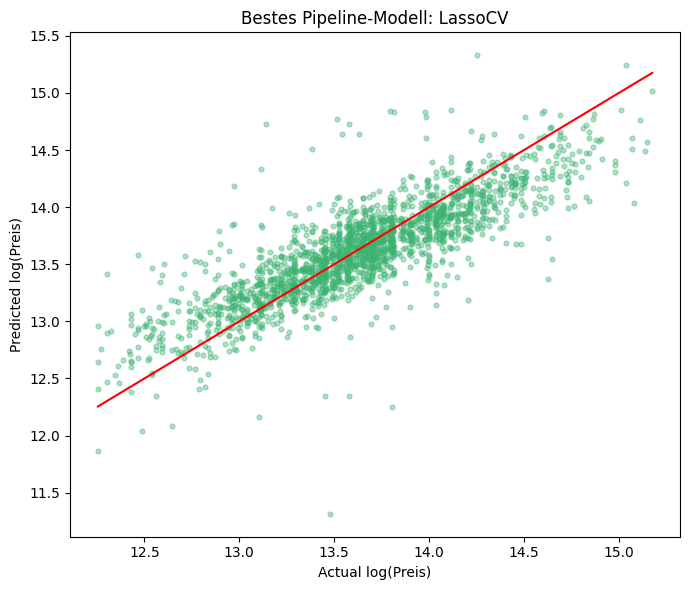

In [ ]:

# ── Scikit-Learn Pipeline ─────────────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import (
    LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV, LassoLarsCV
)
from sklearn.metrics import mean_absolute_percentage_error

# ── 1. Column groups ──────────────────────────────────────────────────────────
cat_cols = [c for c in ['municipality_name', 'object_type_name', 'zipcode']
            if c in X_train.columns]

# Features where log1p makes sense (skewed, positive)
log_cols = [c for c in ['living_area', 'num_rooms', 'water_percentage_1000',
                         'travel_time_private_transport', 'travel_time_public_transport',
                         'number_of_buildings_in_hectare', 'number_of_apartments_in_hectare']
            if c in X_train.columns]

# Remaining numeric features (pass through with imputation only)
num_cols = [c for c in X_train.select_dtypes(include=['float64', 'int64']).columns
            if c not in log_cols]

print(f"Kategorisch  ({len(cat_cols)}): {cat_cols}")
print(f"Log-transform({len(log_cols)}): {log_cols}")
print(f"Numerisch    ({len(num_cols)}): {num_cols}")

# ── 2. Sub-pipelines per column group ─────────────────────────────────────────
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
])

log_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log',     FunctionTransformer(np.log1p, validate=True)),
])

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

# ── 3. ColumnTransformer ──────────────────────────────────────────────────────
preprocessor = ColumnTransformer([
    ('cat', cat_pipe, cat_cols),
    ('log', log_pipe, log_cols),
    ('num', num_pipe, num_cols),
], remainder='drop')

# ── 4. Compare models inside the pipeline ─────────────────────────────────────
# NOTE: StandardScaler is important for regularized models (Ridge, Lasso, ElasticNet).
#       Without it, features with large values get penalized more than features with
#       small values, leading to biased regularization. For LinearRegression it has
#       no effect on predictions, but is good practice for numerical stability.

models = {
    'LinearRegression': LinearRegression(),
    'Ridge':            Ridge(),
    'RidgeCV':          RidgeCV(),
    'Lasso':               Lasso(),
    'LassoCV':          LassoCV(cv=5, max_iter=10000),
    'LassoLarsCV':      LassoLarsCV(cv=5),
    'ElasticNet':       ElasticNet(),
    'ElasticNetCV':     ElasticNetCV(cv=5, max_iter=10000),
}

pipeline_results = {}
for name, estimator in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('scaler',       StandardScaler()),   # ← crucial for regularized models
        ('model',        estimator),
    ])
    pipe.fit(X_train, y_log_train)
    y_pred = pipe.predict(X_val)
    mape = mean_absolute_percentage_error(np.exp(y_log_val), np.exp(y_pred))
    pipeline_results[name] = {'mape': mape, 'pipe': pipe, 'y_pred': y_pred}
    print(f"MAPE {name:20s}: {mape:.4f}")

# ── 5. Bar chart ──────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.bar(pipeline_results.keys(),
        [v['mape'] for v in pipeline_results.values()],
        color='mediumseagreen')
plt.xlabel('Model')
plt.ylabel('MAPE')
plt.title('Pipeline: Model Comparison (OHE + log + StandardScaler)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# ── 6. Best model – predicted vs. actual ─────────────────────────────────────
best_name = min(pipeline_results, key=lambda k: pipeline_results[k]['mape'])
best_pred = pipeline_results[best_name]['y_pred']
print(f"\nBestes Modell: {best_name}  (MAPE: {pipeline_results[best_name]['mape']:.4f})")

plt.figure(figsize=(7, 6))
plt.scatter(y_log_val, best_pred, alpha=0.4, s=12, color='mediumseagreen')
plt.plot([y_log_val.min(), y_log_val.max()],
         [y_log_val.min(), y_log_val.max()], color='red', lw=1.5)
plt.xlabel('Actual log(Preis)')
plt.ylabel('Predicted log(Preis)')
plt.title(f'Bestes Pipeline-Modell: {best_name}')
plt.tight_layout()
plt.show()


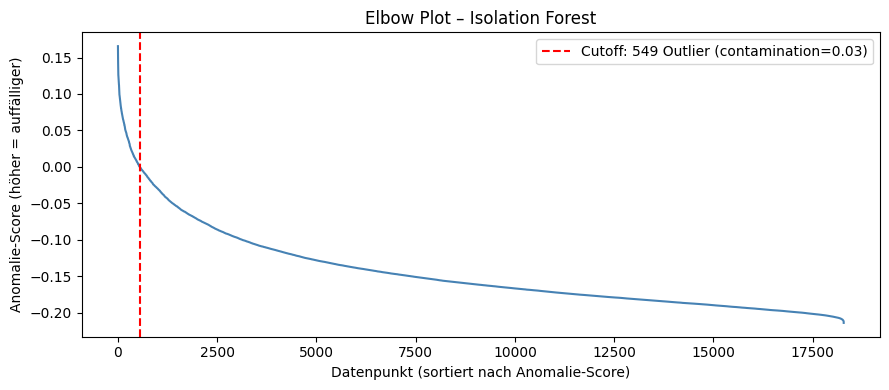

Outlier: 549 von 18281 (3.0 %)


In [86]:

# ── Outlier Detection mit Isolation Forest ────────────────────────────────────
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Features vorbereiten
od_features = ['living_area', 'num_rooms', 'build_year',
               'travel_time_private_transport', 'travel_time_public_transport',
               'number_of_buildings_in_hectare', 'number_of_apartments_in_hectare']
od_features = [c for c in od_features if c in X_train.columns]

X_od = StandardScaler().fit_transform(
    SimpleImputer(strategy='median').fit_transform(X_train[od_features])
)

# contamination steuert wie viele Outlier erkannt werden:
#   → erhöhen (z.B. 0.10): Linie verschiebt sich nach RECHTS (mehr Outlier)
#   → verringern (z.B. 0.02): Linie verschiebt sich nach LINKS (weniger Outlier)
contamination = 0.03

iso = IsolationForest(n_estimators=200, contamination=contamination, random_state=42)
iso.fit(X_od)

outlier_mask = iso.predict(X_od) == -1
n_outliers = outlier_mask.sum()

# Anomalie-Scores absteigend → Elbow-Form
anomaly_scores = np.sort(-iso.decision_function(X_od))[::-1]

plt.figure(figsize=(9, 4))
plt.plot(anomaly_scores, color='steelblue', lw=1.5)
plt.axvline(n_outliers, color='red', ls='--', lw=1.5,
            label=f'Cutoff: {n_outliers} Outlier (contamination={contamination})')
plt.xlabel('Datenpunkt (sortiert nach Anomalie-Score)')
plt.ylabel('Anomalie-Score (höher = auffälliger)')
plt.title('Elbow Plot – Isolation Forest')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Outlier: {n_outliers} von {len(outlier_mask)} ({outlier_mask.mean()*100:.1f} %)")


In [92]:

# ── Feature Engineering + Modell-Experimente ─────────────────────────────────
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_percentage_error

from xgboost import XGBRegressor
from catboost import CatBoostRegressor



def add_features(df):
    df = df.copy()
    if 'build_year' in df.columns:
        df['building_age'] = (2026 - df['build_year']).clip(lower=0)
        df['is_new']       = (df['build_year'] >= 2000).astype(int)
        df['is_historic']  = (df['build_year'] < 1950).astype(int)
    if 'living_area' in df.columns and 'num_rooms' in df.columns:
        df['area_per_room'] = df['living_area'] / df['num_rooms'].replace(0, np.nan)
    if 'number_of_apartments_in_hectare' in df.columns and 'number_of_buildings_in_hectare' in df.columns:
        df['apt_per_building'] = (df['number_of_apartments_in_hectare'] /
                                   df['number_of_buildings_in_hectare'].replace(0, np.nan))
    if 'travel_time_private_transport' in df.columns and 'travel_time_public_transport' in df.columns:
        df['transport_ratio']   = (df['travel_time_private_transport'] /
                                   df['travel_time_public_transport'].replace(0, np.nan))
        df['total_travel_time'] = (df['travel_time_private_transport'] +
                                   df['travel_time_public_transport'])
    return df

X_train_fe = add_features(X_train)
X_val_fe   = add_features(X_val)

# Outlier entfernen (outlier_mask aus Isolation-Forest-Zelle)
X_train_fe_clean     = X_train_fe[~outlier_mask].copy()
y_log_train_fe_clean = y_log_train[~outlier_mask]
print(f"Trainingsset: {len(X_train_fe)} → {len(X_train_fe_clean)} Zeilen (−{outlier_mask.sum()} Outlier)\n")

# ── Location Encoding (Target Encoding) ──────────────────────────────────────
# Mittelwert des log-Preises pro Gemeinde (nur aus Clean-Train berechnen → kein Leakage)
loc_stats = (pd.Series(y_log_train_fe_clean.values, index=X_train_fe_clean.index)
               .groupby(X_train_fe_clean['municipality_name']).mean())
global_mean = loc_stats.mean()

X_train_fe_clean['muni_mean_log_price'] = (
    X_train_fe_clean['municipality_name'].map(loc_stats).fillna(global_mean))
X_val_fe = X_val_fe.copy()
X_val_fe['muni_mean_log_price'] = (
    X_val_fe['municipality_name'].map(loc_stats).fillna(global_mean))

# ── Preprocessing ─────────────────────────────────────────────────────────────
cat_cols_fe = [c for c in ['municipality_name', 'object_type_name', 'zipcode']
               if c in X_train_fe_clean.columns]
log_cols_fe = [c for c in ['living_area', 'num_rooms', 'area_per_room',
                             'number_of_buildings_in_hectare', 'number_of_apartments_in_hectare',
                             'apt_per_building', 'building_age',
                             'travel_time_private_transport', 'travel_time_public_transport',
                             'total_travel_time', 'muni_mean_log_price']
               if c in X_train_fe_clean.columns]
num_cols_fe = [c for c in X_train_fe_clean.select_dtypes(include=['float64', 'int64']).columns
               if c not in log_cols_fe]

preprocessor_fe = ColumnTransformer([
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))]),
     cat_cols_fe),
    ('log', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('log', FunctionTransformer(np.log1p, validate=True))]),
     log_cols_fe),
    ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]),
     num_cols_fe),
], remainder='drop')

# ── Modelle – hier beliebig austauschen / ergänzen ───────────────────────────
fe_models = {
    'HistGradientBoosting': HistGradientBoostingRegressor(
        max_iter=1000, learning_rate=0.05, max_depth=6,
        min_samples_leaf=20, random_state=42,
    ),
    'XGBoost': XGBRegressor(
        n_estimators=1000, learning_rate=0.03, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0,
    ),
    'CatBoost': CatBoostRegressor(
        iterations=1000, learning_rate=0.05, depth=6,
        l2_leaf_reg=3, verbose=0, random_state=42,
    ),
}

for name, estimator in fe_models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor_fe),
        ('scaler',       StandardScaler()),
        ('model',        estimator),
    ])
    pipe.fit(X_train_fe_clean, y_log_train_fe_clean)
    y_pred = pipe.predict(X_val_fe)
    mape   = mean_absolute_percentage_error(np.exp(y_log_val), np.exp(y_pred))
    print(f"MAPE {name:30s}: {mape:.4f}")

# ── CatBoost nativ (ohne OHE, direkt mit Kategorien) ─────────────────────────
# CatBoost kennt Kategorien nativ → keine OHE nötig, oft besser bei hoher Kardinalität
print("\n── CatBoost nativ ──")
from sklearn.impute import SimpleImputer as SI

X_cb_train = X_train_fe_clean.copy()
X_cb_val   = X_val_fe.copy()

cat_cb   = ['municipality_name', 'object_type_name', 'zipcode']
num_cb   = [c for c in X_cb_train.columns if c not in cat_cb]

# Numerics: Median-Imputation
imp_num = SI(strategy='median')
X_cb_train[num_cb] = imp_num.fit_transform(X_cb_train[num_cb])
X_cb_val[num_cb]   = imp_num.transform(X_cb_val[num_cb])

# Kategorien: NaN → 'unknown', dann String
for c in cat_cb:
    X_cb_train[c] = X_cb_train[c].fillna('unknown').astype(str)
    X_cb_val[c]   = X_cb_val[c].fillna('unknown').astype(str)

cat_idx = [X_cb_train.columns.tolist().index(c) for c in cat_cb]

cb_native = CatBoostRegressor(
    iterations=1500, learning_rate=0.04, depth=6,
    l2_leaf_reg=3, verbose=0, random_state=42,
)
cb_native.fit(X_cb_train, y_log_train_fe_clean,
              cat_features=cat_idx,
              eval_set=(X_cb_val, y_log_val))
y_pred_cb = cb_native.predict(X_cb_val)
mape_cb   = mean_absolute_percentage_error(np.exp(y_log_val), np.exp(y_pred_cb))
print(f"MAPE {'CatBoost nativ':30s}: {mape_cb:.4f}")


Trainingsset: 18281 → 17732 Zeilen (−549 Outlier)

MAPE HistGradientBoosting          : 0.1895
MAPE XGBoost                       : 0.1877
MAPE CatBoost                      : 0.1870

── CatBoost nativ ──
MAPE CatBoost nativ                : 0.1801


# Define and train model

After the Data Analysis, we are ready to train a model.

We recommend starting with a very simple model. We can try more complex ones later.

Try for example a LinearRegression with only the two features "living_area" and "num_rooms".

After submitting the results of this simple model we can try more things. Like OneHotEncoding categorical features or other models.

Here is the link to the sklearn documentation and an example for the LinearRegression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

In [6]:
# TODO: Define and train your model here

## Predict and evaluate prices for the validation set

After we have trained our model, we will evaluate it on the validation set.

We will use the MAPE metric (https://en.wikipedia.org/wiki/Mean_absolute_percentage_error) for evaluation in this example project.
The MAPE metric is not available in the sklearn.metric package therefore we have implemented it ourselves here.

Note that if you will start your own project, defining which metric to use is an important step.
If you want to learn more about often used metrics that are available in sklearn: https://scikit-learn.org/stable/modules/model_evaluation.html

Note that MAPE is also defined in sklearn (since 2020): https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_percentage_error.html

In [7]:
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [8]:
# Note that in this skeleton we do not have a model. Therefore, we predict randomly.
# After you have defined and trained your model in the previous step, you should use it here to make the predictions.
y_val_pred = [np.mean(y_train)] * len(y_val)

After predicting for the validation set we can use the MAPE metric to see how good we are.

In [9]:
# How good are we on the validation data?
# The random predictions from our skeleton are of course quit bad.
print(mean_absolute_percentage_error(y_val, y_val_pred))

53.970026682491536
